## **TF-IDF Exercise**

### TF-IDF: Exercises

Humans 👦 show different emotions/feelings based on the situations and communicate them through facial expressions or in form of words.

In Social Media like Twitter and Instagram, many people express their views through comments about a particular event/scenario and these comments may address the feelings like sadness, happiness, joy, sarcasm, fear, and many other.

For a given comment/text, we are going to use classical NLP techniques and classify under which emotion that particular comment belongs!

We are going to use techniques like Bag of grams, n-grams, TF-IDF, etc. for text representation and apply different classification algorithms.

### About Data: Emotion Detection

Credits: https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp

This data consists of two columns. - Comment - Emotion

Comment are the statements or messages regarding to a particular event/situation.

Emotion feature tells whether the given comment is fear 😨, Anger 😡, Joy 😂.

As there are only 3 classes, this problem comes under the Multi-Class Classification.

In [1]:
#import pandas library
import pandas as pd

#read the dataset with name "Emotion_classify_Data.csv" and store it in a variable df
df= pd.read_csv('Emotion_classify_Data.csv')
#print the shape of dataframe
print(df.shape)
#print top 5 rows
print(df.head())

(5937, 2)
                                             Comment Emotion
0  i seriously hate one subject to death but now ...    fear
1                 im so full of life i feel appalled   anger
2  i sit here to write i start to dig out my feel...    fear
3  ive been really angry with r and i feel like a...     joy
4  i feel suspicious if there is no one outside l...    fear


In [2]:
#check the distribution of Emotion
print(df.Emotion.value_counts())

Emotion
anger    2000
joy      2000
fear     1937
Name: count, dtype: int64


* From the above, we can see that almost the Emotions(classes) occured equal number of times and balanced. There is no problem of class imbalance and hence no need to apply any balancing techniques like undersampling, oversampling etc.

In [4]:
#Add the new column "Emotion_num" which gives a unique number to each of these Emotions

df['Emotion_num'] = df.Emotion.map({
    'joy' : 0,
    'fear': 1,
    'anger': 2
})
df.head()

,Comment,Emotion,Emotion_num
0,i seriously hate one subject to death but now ...,fear,1
1,im so full of life i feel appalled,anger,2
2,i sit here to write i start to dig out my feel...,fear,1
3,ive been really angry with r and i feel like a...,joy,0
4,i feel suspicious if there is no one outside l...,fear,1


## Modelling without Pre-processing Text data

In [7]:
#Do the 'train-test' splitting with test size of 20%
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    df.Comment,
    df.Emotion_num,
    test_size=0.2,
    random_state=2022,
    stratify= df.Emotion_num
)

# Printing distributions and shapes
print("X-Train shape : ",X_train.shape)
print("y-Train shape : ",y_train.shape)
print("y-Train distribution : ",y_train.value_counts())
print("X-test shape : ",X_test.shape)
print("y-test shape : ",y_test.shape)
print("y-Test distribution : ",y_test.value_counts())


X-Train shape :  (4749,)
y-Train shape :  (4749,)
y-Train distribution :  Emotion_num
0    1600
2    1600
1    1549
Name: count, dtype: int64
X-test shape :  (1188,)
y-test shape :  (1188,)
y-Test distribution :  Emotion_num
0    400
2    400
1    388
Name: count, dtype: int64


## Attempt 1 :

using the sklearn pipeline module create a classification pipeline to classify the data.

Note:

* using CountVectorizer with only trigrams.
* use RandomForest as the classifier.
* print the classification report.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report

clf = Pipeline([
    ('count_vectorizer',CountVectorizer(ngram_range=(3,3))),
    ('random_forest',RandomForestClassifier()),
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.58      0.24      0.35       400
           1       0.36      0.81      0.50       388
           2       0.53      0.21      0.30       400

    accuracy                           0.42      1188
   macro avg       0.49      0.42      0.38      1188
weighted avg       0.49      0.42      0.38      1188



## Attempt 2 :

using the sklearn pipeline module create a classification pipeline to classify the data.

Note:

* using CountVectorizer with both unigram and bigrams.
* use Multinomial Naive Bayes as the classifier.
* print the classification report.*

In [17]:
from sklearn.naive_bayes import MultinomialNB

clf = Pipeline([
    ('cnt_vec_uni_and_bi',CountVectorizer(ngram_range=(1,2))),
    ('nb',MultinomialNB(alpha=0.25))
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       400
           1       0.85      0.83      0.84       388
           2       0.82      0.87      0.84       400

    accuracy                           0.84      1188
   macro avg       0.85      0.84      0.84      1188
weighted avg       0.85      0.84      0.84      1188



## Attempt 3 :

using the sklearn pipeline module create a classification pipeline to classify the data.

Note:

* using CountVectorizer with both unigram and bigrams.
* use RandomForest as the classifier.
* print the classification report.

In [20]:
clf = Pipeline([
    ('count_vectorizer',CountVectorizer(ngram_range=(1,2))),
    ('random_forest',RandomForestClassifier()),
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89       400
           1       0.96      0.88      0.91       388
           2       0.93      0.86      0.89       400

    accuracy                           0.90      1188
   macro avg       0.91      0.90      0.90      1188
weighted avg       0.90      0.90      0.90      1188



## Attempt 4 :

using the sklearn pipeline module create a classification pipeline to classify the Data.

Note:

* using TF-IDF vectorizer for pre-processing the text.
* use RandomForest as the classifier.
* print the classification report.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

clf = Pipeline([
    ('tfidf_vectorizer',TfidfVectorizer()),
    ('random_forest',RandomForestClassifier()),
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       400
           1       0.91      0.90      0.91       388
           2       0.94      0.88      0.91       400

    accuracy                           0.90      1188
   macro avg       0.91      0.90      0.90      1188
weighted avg       0.91      0.90      0.90      1188



## Use text pre-processing to remove stop words, punctuations and apply lemmatization

In [23]:
import spacy 

nlp = spacy.load("en_core_web_sm")

#use this utility function to get the preprocessed text data
def preprocess(text):
    doc = nlp(text)
    preprocessed_text = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return " ".join(preprocessed_text)

In [24]:
# create a new column "preprocessed_comment" and use the utility function above to get the clean data
# this will take some time, please be patient
df['preprocessed_comment'] = df.Comment.apply(preprocess)
df.head()


,Comment,Emotion,Emotion_num,preprocessed_comment
0,i seriously hate one subject to death but now ...,fear,1,seriously hate subject death feel reluctant drop
1,im so full of life i feel appalled,anger,2,m life feel appalled
2,i sit here to write i start to dig out my feel...,fear,1,sit write start dig feeling think afraid accep...
3,ive been really angry with r and i feel like a...,joy,0,ve angry r feel like idiot trust place
4,i feel suspicious if there is no one outside l...,fear,1,feel suspicious outside like rapture happen


In [25]:
# Build a model with pre processed text

X_train,X_test,y_train,y_test = train_test_split(
    df.preprocessed_comment,
    df.Emotion_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.Emotion_num
)


Let's check the scores with our best model till now
* Random Forest

## Attempt1 :

using the sklearn pipeline module create a classification pipeline to classify the data.

Note:

* using CountVectorizer with both unigrams and bigrams.
* use RandomForest as the classifier.
* print the classification report.

In [27]:
clf = Pipeline([
    ('cnt_vectorizer',CountVectorizer(ngram_range=(1,2))),
    ('random_forest',RandomForestClassifier()),
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       400
           1       0.94      0.91      0.92       388
           2       0.92      0.93      0.92       400

    accuracy                           0.93      1188
   macro avg       0.93      0.93      0.93      1188
weighted avg       0.93      0.93      0.93      1188



* Results without Preprocessing (For comparision)
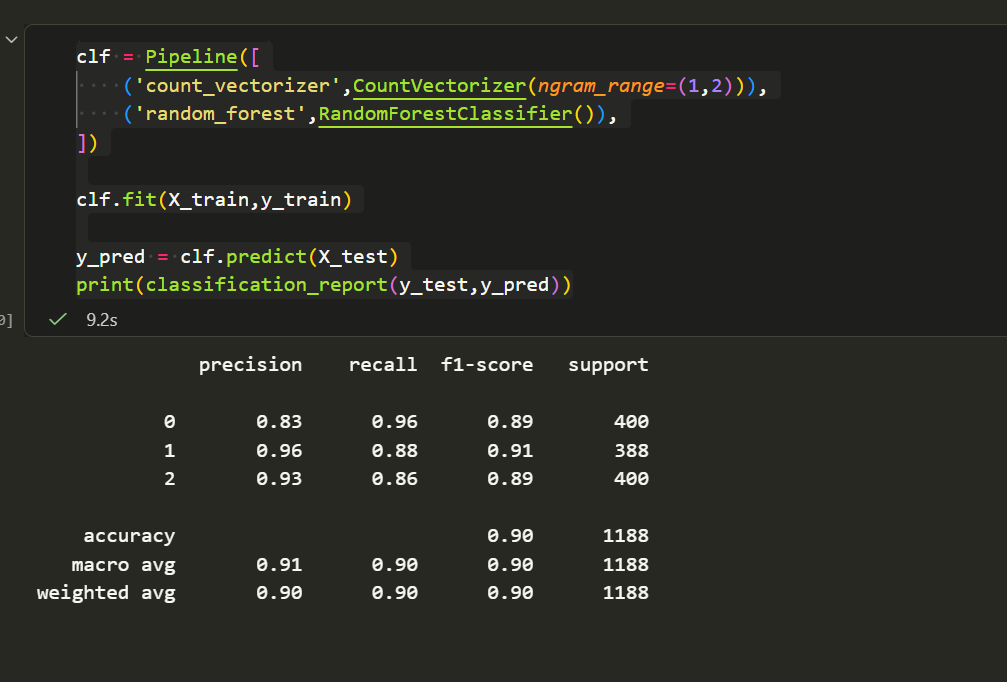

## Attempt 2 :

using the sklearn pipeline module create a classification pipeline to classify the data.

Note:

* using TF-IDF vectorizer for pre-processing the text.
* use RandomForest as the classifier.
* print the classification report.

In [32]:
clf = Pipeline([
    ('tfidf_vectorizer',TfidfVectorizer()),
    ('random_forest',RandomForestClassifier()),
])

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       400
           1       0.94      0.93      0.93       388
           2       0.94      0.91      0.92       400

    accuracy                           0.93      1188
   macro avg       0.93      0.93      0.93      1188
weighted avg       0.93      0.93      0.93      1188



## **Final Observations**
* As part of this exercise we have trained the data with algorithms like Multinomial Naive Bayes and Random Forest which are most used and provide good results for text related problems.

* As Machine learning algorithms do not work on text data directly, we need to convert them into numeric vectors and feed that into models while training. For this purpose, we have used Bag of words(unigrams, bigrams, n-grams) and TF-IDF text representation techniques.

### Key Findings

* As the n_gram range keeps increasing, there's drastic fall of improvement in performance metrics.
* There's seen a significant improvement in results before pre-processing and after pre-processing the data.
* TF-IDF and Bag of words both performed equally well in performance metrics like Recall and F1-score.
* Random Forest performed quite well when compared to Multinomial Naive Bayes.

**Machine Learning is like a trial and error scientific method, where we keep trying all the possible algorithms we have and select the one which gives good results and satisfies the requirements like latency, interpretability, etc.**